# Invasion analysis 

This notebook contains example code that was used to classify GBM cells as invasive or not and assess how ecEGFR phenotypes vary across invasion status. Input requires single cell object(s) with malignant cluster annotations and non-malignant status annotations. 

In [1]:
import sys
import subprocess
import numpy as np
import pandas as pd
import scanpy as sc
import anndata
from anndata import AnnData
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os
import monkeybread as mb

C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\anndata\utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\anndata\utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\anndata\utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\anndata\utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\anndata\utils.py:434: FutureWarning: Importing 

In [2]:
# read in human 
adatah = sc.read_h5ad(r"D:\BT\ecEGFR\sc_objects\20250925_GBM39_invivo_human_mouse_1_w_updated_cell_states.h5ad")

In [3]:
import pandas as pd
import numpy as np

def add_butterfly_state_cluster(
    adata,
    cluster_col="leiden",                  # source Leiden cluster column
    new_col="butterfly_state_cluster"
):
    if cluster_col not in adata.obs.columns:
        raise KeyError(f"'{cluster_col}' not found in adata.obs")

    # Your mapping by Leiden cluster index
    cluster_to_state = {
        0: "0_AC",
        1: "1_MES",
        2: "2_MES",
        3: "3_MES",
        4: "4_MES",
        5: "5_MES",
        6: "6_OPC",
    }

    # Handle common Leiden formats (often strings like "0","1",… and categorical dtype)
    col = adata.obs[cluster_col]

    # Convert to numeric cluster index when possible
    # (strings like "0" -> 0; anything non-numeric becomes NaN then unmapped)
    cluster_idx = pd.to_numeric(pd.Series(col.astype(str).values, index=col.index), errors="coerce")

    # Map to state labels
    mapped = cluster_idx.map(cluster_to_state)

    # Anything not in the mapping becomes "Unlabeled"
    mapped = mapped.fillna("Unlabeled")

    # Make it a tidy categorical (you can tweak order if you prefer)
    cats = ["0_AC", "1_MES", "2_MES", "3_MES","4_MES","5_MES","6_OPC",]
    mapped = pd.Categorical(mapped, categories=cats, ordered=False)

    adata.obs[new_col] = mapped

    # Optional: quick sanity prints (comment out if running non-interactively)
    print(f"Added '{new_col}' from '{cluster_col}'.")
    print(adata.obs[new_col].value_counts(dropna=False))

# --- run it ---
add_butterfly_state_cluster(adatah, cluster_col="leiden", new_col="butterfly_state_cluster")

Added 'butterfly_state_cluster' from 'leiden'.
butterfly_state_cluster
0_AC     5702
1_MES    5538
2_MES    5065
3_MES    4012
4_MES    2636
5_MES    2618
6_OPC     492
Name: count, dtype: int64


In [4]:
adatam = sc.read(r"D:\BT\ecEGFR\sc_objects\20250817_ecEGFR_xenograft_mouse_4_w_40_41.h5ad")
adatam

C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\anndata\__init__.py:42: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


AnnData object with n_obs × n_vars = 54978 × 275
    obs: 'volm', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'old_leiden', 'Malat1', 'MALAT1', 'ecDNA_cts1', 'ecDNA_cts2', 'RgRatio1', 'RgRatio2', 'human_cancer', 'mouse_normal', 'P1F12_ecEGFR_mean_counts', 'log2_P1F12_ecEGFR_mean_counts', 'all_hybes_ecEGFR_mean_counts', 'log2_all_hybes_ecEGFR_mean_counts', 'species', 'leiden', 'score__Astro_Epen', 'score__CB_GABA', 'score__CB_Glut', 'score__CNU_HYa_GABA', 'score__CNU_HYa_Glut', 'score__CNU_LGE_GABA', 'score__CNU_MGE_GABA', 'score__CTX_CGE_GABA', 'score__CTX_MGE_GABA', 'score__DG_IMN_Glut', 'score__HY_GABA', 'score__HY_Glut', 'score__HY_MM_Glut', 'score__IT_ET_Glut', 'score__Immune', 'score__LSX_GABA', 'score__MB_Dopa', 'score__MB_GABA', 'score__MB_Glut', 'score__MB_HB_Sero', 'score__MH_LH_Glut', 'score__MY_GABA', 'score__MY_Glut', 'score__NP_CT_L6b_Glut', 'score__OB_CR_Glut', 'score__OB_IMN_GABA', 'score__OEC', 'score__OPC_Oligo', 'score__P_GABA

## GBM fraction/neighbors
We defined invasion by computing the fraction of malignant neighbors for each malignant cell. That is to say, within a given radius, how many of the cells next to a given cell are malignant vs. non-malignant? The more non-malignant neighbors a cell has, the more likely it is invasive. Parameters include the radius, and the malignant fraction threshold at which a cell is invasive. For our paper, we chose a 200 um radius and a malignant fraction <0.25 to define invasiveness; however, the biological conclusions are relatively robust to changing parameters.

In [5]:
import anndata as ad
import numpy as np
import pandas as pd

# --- copies so we don’t mutate originals ---
adatah = adatah.copy()
adatam = adatam.copy()

# 1) Make cell IDs unique and tag species
for a, sp in [(adatah, "human"), (adatam, "mouse")]:
    a.obs_names_make_unique()
    a.obs["species"] = sp

# 2) (optional) make sure both are in the same orientation/units
# If you previously rotated/mirrored one of them, apply the same transform to the other before concat.

# 3) Concatenate (outer join = union of genes; missing genes become 0)
adata = ad.concat(
    {"human": adatah, "mouse": adatam},
    axis=0,
    join="outer",
    label="species",        # writes 'human'/'mouse' into adata.obs['species']
    index_unique="-"        # avoids obs name collisions by key-prefixing if needed
)

# 4) Build a single cell-type label to use for neighborhoods
#    (adjust these column names to what you actually have)
H_COL = "butterfly_state_cluster"                 # e.g. 'AC-like','MES-like','OPC-like','Ambiguous'
M_COL = "marker_genes_identity_v2"    # e.g. 'OPCs','TAMs','Endothelial', etc.

celltype = pd.Series(index=adata.obs_names, dtype="object")
mask_h = adata.obs["species"].eq("human")
mask_m = ~mask_h
celltype.loc[mask_h] = adata.obs.loc[mask_h, H_COL].astype(str) + " (GBM)"
celltype.loc[mask_m] = adata.obs.loc[mask_m, M_COL].astype(str) + " (mouse)"
adata.obs["celltype_merged_2"] = pd.Categorical(celltype)

# (nice-to-have) convert all string obs columns to 'category' to avoid h5py write issues
for c in adata.obs.columns:
    if pd.api.types.is_string_dtype(adata.obs[c]):
        adata.obs[c] = adata.obs[c].astype("category")

In [6]:
import re
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from scipy import sparse
import seaborn as sns
import matplotlib.pyplot as plt

# --- your normalizers (re-use) ---
def norm_cluster_tag(s):
    m = s.astype(str).str.extract(r'^(?P<num>\d+)_(?P<state>AC|MES|OPC|NPC)\s*\(GBM\)$')
    out = pd.Series(index=s.index, dtype="object")
    ok = m.notna().all(1)
    out.loc[ok] = (m.loc[ok, "num"].astype(int).astype(str) + "_" + m.loc[ok, "state"]).values
    return out

def norm_state_only(s):
    return s.astype(str).str.extract(r'^(AC|MES|OPC|NPC)\s*\(GBM\)$')[0]

def gbm_mask_from_obs(adata):
    if "celltype_merged_2" not in adata.obs:
        raise KeyError("Need adata.obs['celltype_merged_2'] to detect GBM cells.")
    return adata.obs["celltype_merged_2"].astype(str).str.contains(r"\(GBM\)$").to_numpy()

# =========================
# 1) GBM neighbor fraction BY GROUP (generic)
# =========================
def compute_gbmfrac_by_group(
    adata,
    obs_col: str,
    radii=(25, 50, 100, 200),
    *,
    normalize_fn=None,          # e.g., norm_cluster_tag / norm_state_only / None
    include_values=None,        # whitelist labels after normalization
    exclude_values=None,        # blacklist labels after normalization
    focal="gbm_only",           # "gbm_only" (typical) or "all"
    sample_col="sample",
    n_perms=0,                  # set >0 to get a null (shuffles GBM mask within-sample)
    random_state=42,
    x_key="X_spatial",
    store_prefix=None
):
    """
    Per focal cell i in selected groups:
      GBMFrac_i(r) = (# malignant neighbors within r) / (# all neighbors within r)

    Neighbors: ALL cells.
    Focal set: cells with non-NaN label from `obs_col` (optionally restricted to GBM with focal='gbm_only').
    Writes per-cell columns to adata.obs: f"{prefix}_r{r}"

    Returns:
      summary_df (per-group, per-radius; includes optional null mean/sd & p-values if n_perms>0),
      created_cols (list of per-cell column names)
    """
    rng = np.random.default_rng(random_state)
    assert x_key in adata.obsm and adata.obsm[x_key].shape[1] == 2, f"Need adata.obsm['{x_key}'] (N x 2)."
    XY = np.asarray(adata.obsm[x_key], float)
    N  = XY.shape[0]

    # labels for grouping
    raw = adata.obs[obs_col]
    lab = normalize_fn(raw) if normalize_fn is not None else raw.astype(str)
    if include_values is not None:
        lab = lab.where(lab.isin(include_values))
    if exclude_values is not None:
        lab = lab.where(~lab.isin(exclude_values))
    lab = lab.dropna()
    if lab.empty:
        raise ValueError(f"No labels left for '{obs_col}' after normalization/filters.")

    # focal set
    gbm_mask = gbm_mask_from_obs(adata)
    if focal == "gbm_only":
        focal_idx = lab.index[gbm_mask[adata.obs.index.get_indexer(lab.index)]]
    elif focal == "all":
        focal_idx = lab.index
    else:
        raise ValueError("focal must be 'gbm_only' or 'all'")
    if focal_idx.empty:
        raise ValueError("No focal rows after applying 'focal' filter.")

    # encode grouping categories (only for focal rows)
    grp = pd.Categorical(lab.loc[focal_idx])
    grp_names = list(grp.categories)
    codes_q = np.asarray(grp.codes)              # len = n_q
    n_q = len(focal_idx)
    q_iloc = adata.obs.index.get_indexer(focal_idx)

    # malignant indicator over ALL cells
    gbm_vec_all = gbm_mask.astype(int)

    # neighbor index on ALL cells (we’ll exclude self manually)
    nn = NearestNeighbors().fit(XY)

    prefix = store_prefix or f"GBMFrac_by[{obs_col}]"
    created_cols, records = [], []

    # For permutation null (optional): sample groups over ALL cells
    if n_perms > 0 and sample_col in adata.obs.columns:
        samples_all = adata.obs[sample_col].astype(str).values
        pool_groups = {g: np.where(samples_all == g)[0] for g in np.unique(samples_all)}
    else:
        pool_groups = {"_all_": np.arange(N)}

    for r in radii:
        # Build sparse query->all graph without self-edges
        neigh_inds = nn.radius_neighbors(XY[q_iloc], radius=r, return_distance=False)
        data, rows_i, cols_j = [], [], []
        for i, cols in enumerate(neigh_inds):
            cols = cols[cols != q_iloc[i]]
            if cols.size:
                data.extend([1] * cols.size)
                rows_i.extend([i] * cols.size)
                cols_j.extend(cols.tolist())
        G = sparse.csr_matrix((data, (rows_i, cols_j)), shape=(n_q, N))

        deg = np.asarray(G.sum(axis=1)).ravel()
        num = np.asarray(G @ gbm_vec_all).ravel()
        with np.errstate(invalid="ignore", divide="ignore"):
            frac = num / deg
        frac[deg == 0] = np.nan

        col = f"{prefix}_r{int(r)}"
        adata.obs.loc[:, col] = np.nan
        adata.obs.loc[focal_idx, col] = frac
        created_cols.append(col)

        # observed per-group mean
        obs_means = (pd.Series(frac, index=focal_idx)
                     .groupby(pd.Categorical(lab.loc[focal_idx], categories=grp_names))
                     .mean().reindex(grp_names).to_numpy())

        # permutation null: shuffle GBM labels among ALL cells (within sample) while keeping geometry fixed
        if n_perms > 0:
            perm_means = np.zeros((n_perms, len(grp_names)), float)
            for b in range(n_perms):
                gbm_perm = gbm_vec_all.copy()
                for _, idxs in pool_groups.items():
                    gbm_perm[idxs] = rng.permutation(gbm_perm[idxs])
                num_p = np.asarray(G @ gbm_perm).ravel()
                with np.errstate(invalid="ignore", divide="ignore"):
                    frac_p = num_p / deg
                frac_p[deg == 0] = np.nan
                for c in range(len(grp_names)):
                    m = (codes_q == c)
                    perm_means[b, c] = np.nanmean(frac_p[m]) if m.any() else np.nan
            pvals = (np.sum(perm_means >= obs_means[None, :], axis=0) + 1) / (n_perms + 1)
            null_mean = np.nanmean(perm_means, axis=0)
            null_sd   = np.nanstd(perm_means, axis=0, ddof=1)
        else:
            pvals = [np.nan]*len(grp_names)
            null_mean = [np.nan]*len(grp_names)
            null_sd   = [np.nan]*len(grp_names)

        for c_idx, name in enumerate(grp_names):
            records.append({
                "prefix": prefix,
                "obs_col": obs_col,
                "radius": r,
                "group": name,
                "n_cells": int((codes_q == c_idx).sum()),
                "obs_mean_GBMFrac": float(obs_means[c_idx]),
                "null_mean": float(null_mean[c_idx]),
                "null_sd": float(null_sd[c_idx]),
                "p_enrich": float(pvals[c_idx]),
                "focal": focal
            })

    return pd.DataFrame(records), created_cols

# =========================
# 2) Plot human-only densities with hue=group
# =========================
def plot_gbmfrac_by_group_human(adata, prefix, title=""):
    cols = [c for c in adata.obs.columns if c.startswith(prefix+"_r")]
    if not cols:
        raise ValueError(f"No columns found with prefix '{prefix}_r'")
    long = []
    for c in cols:
        r = int(c.split("_r")[-1])
        s = adata.obs[c]
        long.append(pd.DataFrame({
            "radius": r,
            "GBMFrac": s.values,
            "group": adata.obs[prefix.split("by[",1)[1].rstrip("]").split("]")[0]].astype(str).values
        }, index=adata.obs.index))
    df = pd.concat(long).reset_index(names="cell_id")
    # human only
    if "species" in adata.obs:
        df = df.loc[adata.obs["species"].astype(str).str.lower().eq("human").reindex(df["cell_id"]).values]
    df = df.dropna(subset=["GBMFrac","group"])

    sns.set(context="talk", style="whitegrid")
    g = sns.FacetGrid(df, row="radius", hue="group", sharex=True, sharey=False, height=2.6, aspect=1.4)
    g.map(sns.kdeplot, "GBMFrac", bw_method="scott", clip=(0,1), fill=False)
    g.set(xlim=(0,1), xlabel="Fraction malignant neighbors", ylabel="Density")
    g.add_legend(title="Group", bbox_to_anchor=(1.01, 1), loc="upper left", frameon=True)
    g.fig.suptitle(title or "Malignant-neighbor fraction — human", y=1.02)
    plt.tight_layout()
    return g

In [7]:
import seaborn as sns

# choose the exact labels you want to appear (normalized form)
cluster_tag_order = ["0_AC","1_MES","2_MES","3_MES","4_MES","5_MES","6_OPC"]

# fixed palette mapping
cluster_tag_palette = dict(zip(
    cluster_tag_order,
    sns.color_palette("tab10", n_colors=len(cluster_tag_order))
))

In [8]:
df_gbmfrac_tags, cols_tags = compute_gbmfrac_by_group(
    adata,
    obs_col="celltype_merged_2",
    radii=(5,10,25,50,100,200,250,500),
    normalize_fn=norm_cluster_tag,
    focal="gbm_only",
    n_perms=100,
    store_prefix="GBMFrac_by[celltype_merged_2]"
)

C:\Users\cfg001\AppData\Local\Temp\ipykernel_114628\914958387.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(pd.Categorical(lab.loc[focal_idx], categories=grp_names))
C:\Users\cfg001\AppData\Local\Temp\ipykernel_114628\914958387.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(pd.Categorical(lab.loc[focal_idx], categories=grp_names))
C:\Users\cfg001\AppData\Local\Temp\ipykernel_114628\914958387.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=Tru

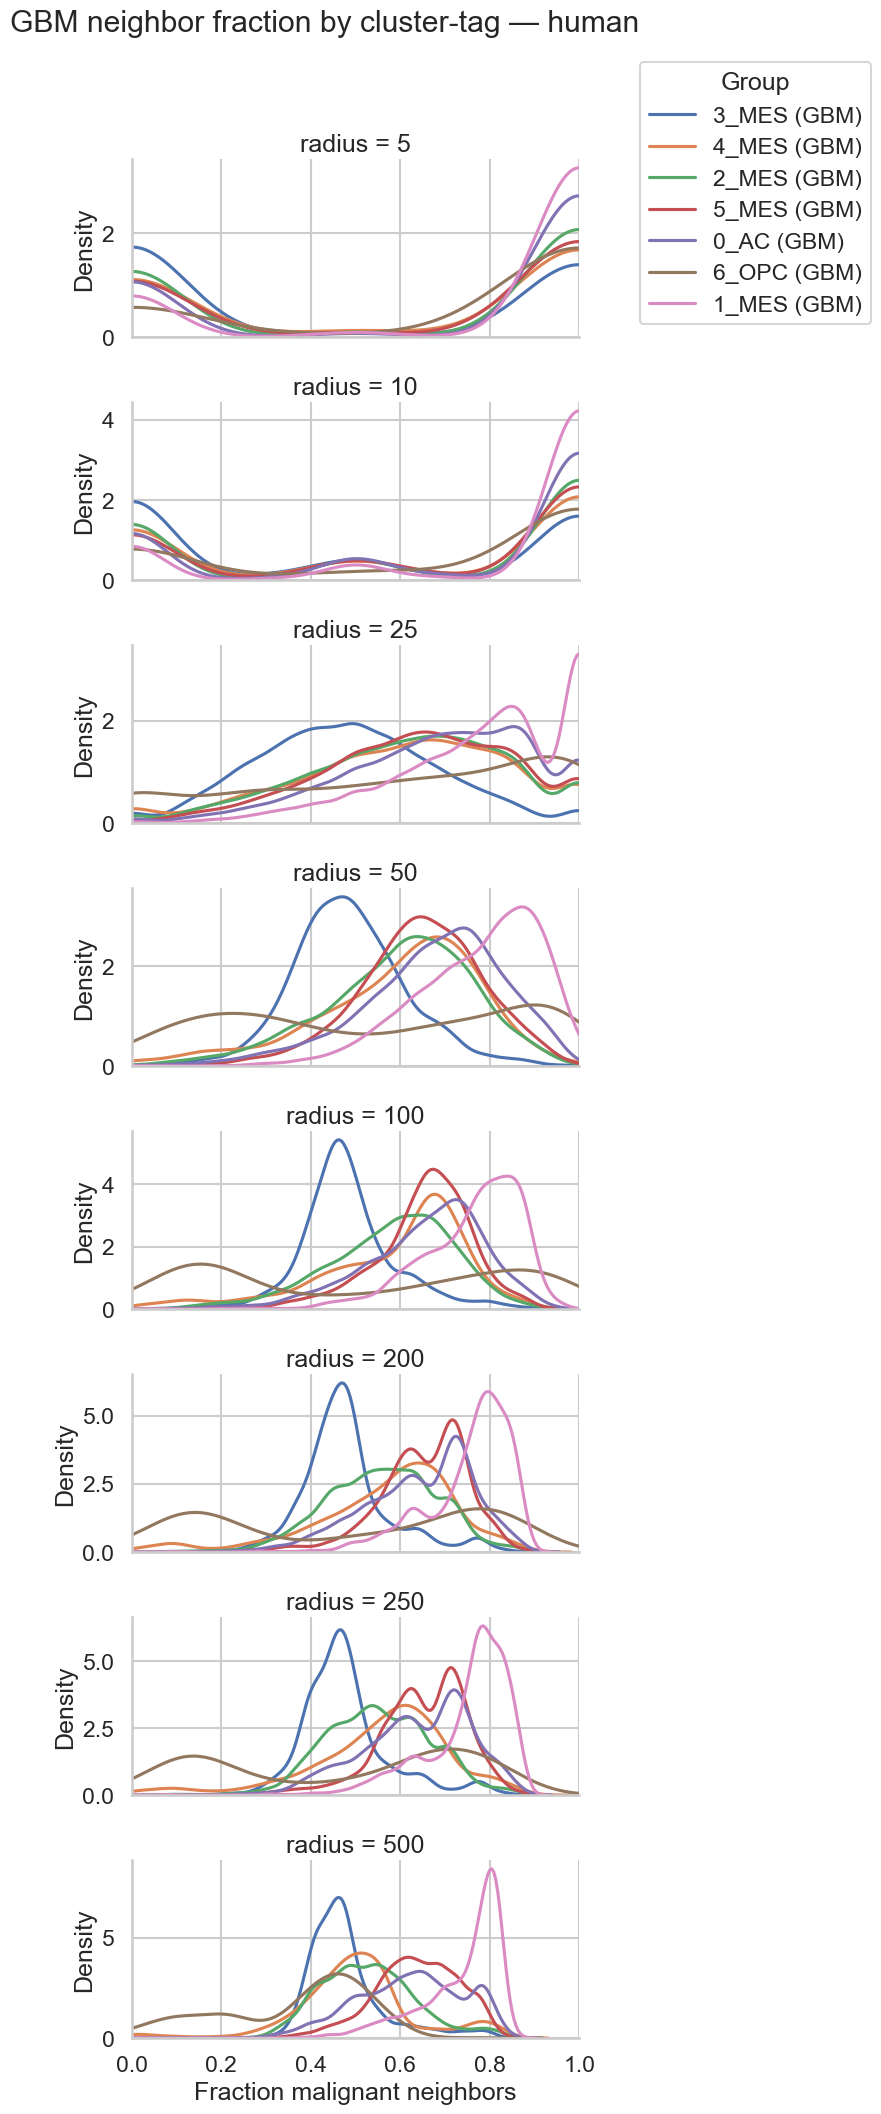

In [9]:
_ = plot_gbmfrac_by_group_human(adata, "GBMFrac_by[celltype_merged_2]",
                                title="GBM neighbor fraction by cluster-tag — human")
plt.show()

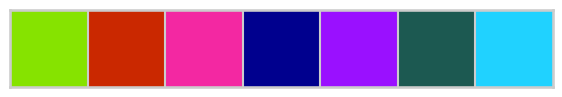

In [10]:
# Want pal7 again to keep colors consistent

pal7 = ['#86e300', '#ca2800', '#f328a2', '#00008e', '#9a10ff','#1c5951', '#20d2ff']
sns.palplot(pal7[:7])

C:\Users\cfg001\AppData\Local\Temp\ipykernel_114628\3638337352.py:88: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


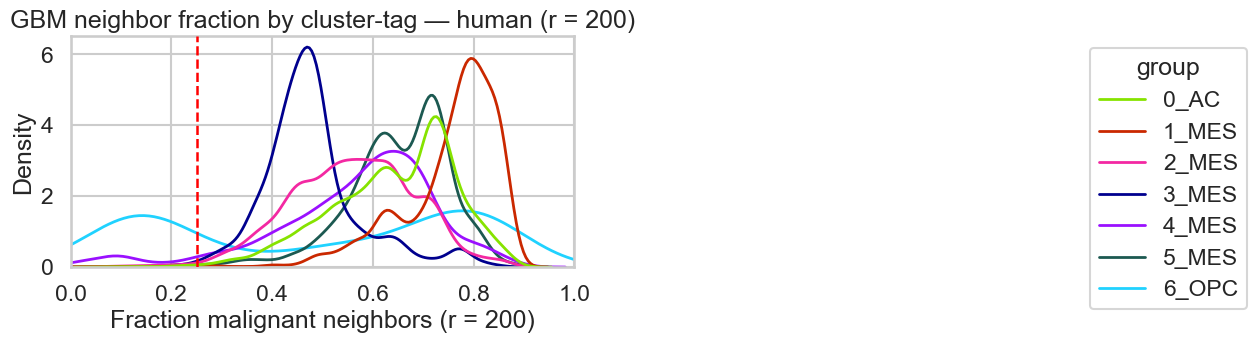

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------------- settings ----------------
prefix = "GBMFrac_by[celltype_merged_2]"
radius = 200
cluster_tag_order = ["0_AC", "1_MES", "2_MES", "3_MES", "4_MES", "5_MES", "6_OPC"]

# optional save path
save_svg = None
# save_svg = r"D:\BT\ecEGFR\manuscript\figures\figure_GBM39_mouse_3\neighbors\GBM39_fraction_neighbors.svg"

# ---------------- palette ----------------
assert len(pal7) >= len(cluster_tag_order), "pal7 does not have enough colors."
palette_map = {lab: pal7[i] for i, lab in enumerate(cluster_tag_order)}

# ---------------- build tidy dataframe ----------------
col = f"{prefix}_r{radius}"
group_series = norm_cluster_tag(adata.obs["celltype_merged_2"])

df = pd.DataFrame(
    {
        "GBMFrac": adata.obs[col].values,
        "group": group_series.values,
    },
    index=adata.obs.index,
)

if "species" in adata.obs:
    is_human = adata.obs["species"].astype(str).str.lower().eq("human").values
    df = df[is_human]

df = df.dropna(subset=["GBMFrac", "group"]).copy()
df["group"] = pd.Categorical(df["group"], categories=cluster_tag_order, ordered=True)
df = df[df["group"].notna()].copy()

# ---------------- plot ----------------
sns.set(context="talk", style="whitegrid")
mpl.rcParams["svg.fonttype"] = "none"  # keep text as text in SVG

fig, ax = plt.subplots(figsize=(6.5, 3.0))

sns.kdeplot(
    data=df,
    x="GBMFrac",
    hue="group",
    hue_order=cluster_tag_order,
    palette=palette_map,
    bw_method="scott",
    clip=(0, 1),
    common_norm=False,
    fill=False,
    linewidth=2,
    legend=False,
    ax=ax,
)

# invasion threshold line
ax.axvline(0.25, ls="--", lw=1.8, c="red", zorder=10)

ax.set(
    xlim=(0, 1),
    xlabel=f"Fraction malignant neighbors (r = {radius})",
    ylabel="Density",
)
ax.set_title(f"GBM neighbor fraction by cluster-tag — human (r = {radius})")

# ---------------- manual legend ----------------
present = df["group"].astype(str).unique()
handles = [
    Line2D([0], [0], color=palette_map[g], lw=2, label=g)
    for g in cluster_tag_order
    if g in present
]

ax.legend(
    handles=handles,
    title="group",
    bbox_to_anchor=(2, 1),
    loc="upper left",
    frameon=True,
)

plt.tight_layout()

# ---------------- save ----------------
if save_svg is not None:
    fig.savefig(save_svg, dpi=1200, bbox_inches="tight")
    print("Saved →", save_svg)

plt.show()

### Defining invasion
Here we set a threshold at .25, such that if 75% of a malignant cell's neighbors are non-malignant, it is defined as invasive. 

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----- settings -----
PREFIX  = "GBMFrac_by[celltype_merged_2]"  # <- matches your compute_gbmfrac_by_group call
RADIUS  = 200                            # choose: 25, 50, 100, or 250
THRESH  = 0.25                           # < 0.25 => invasive; >= 0.25 => non-invasive

gbmfrac_col = f"{PREFIX}_r{int(RADIUS)}"
label_col   = f"invasion_r{int(RADIUS)}"

# sanity check
if gbmfrac_col not in adata.obs.columns:
    raise KeyError(f"Missing {gbmfrac_col}. Run compute_gbmfrac_by_group(...) with radii including {RADIUS}.")

# human GBM mask (only label malignant human cells; others remain NaN)
is_human = adata.obs.get("species", pd.Series("unknown", index=adata.obs.index)).astype(str).str.lower().eq("human")
is_gbm   = adata.obs["celltype_merged_2"].astype(str).str.contains(r"\(GBM\)$", na=False)
mask_gbm_human = (is_human & is_gbm).to_numpy()

vals = adata.obs[gbmfrac_col].to_numpy().astype(float)

lab = np.full(adata.n_obs, np.nan, dtype=object)
lab[(mask_gbm_human) & np.isfinite(vals) & (vals < THRESH)]  = "invasive"
lab[(mask_gbm_human) & np.isfinite(vals) & (vals >= THRESH)] = "non-invasive"

adata.obs[label_col] = pd.Categorical(lab, categories=["invasive","non-invasive"])
print(adata.obs[label_col].value_counts(dropna=False))

invasion_r200
NaN             54978
non-invasive    25640
invasive          423
Name: count, dtype: int64


In [14]:
# Can plot cells spatially by their invasiveness status

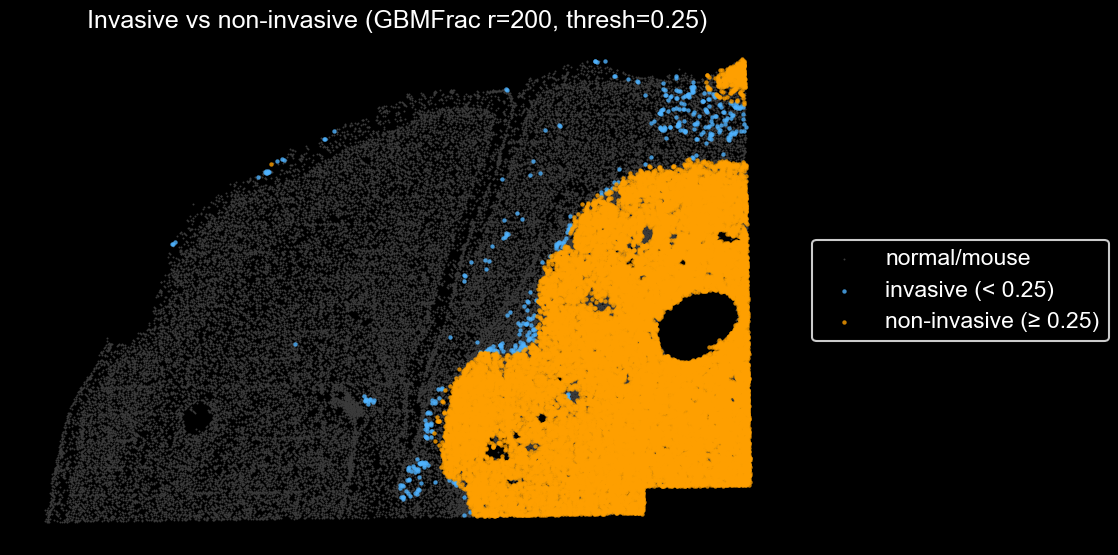

In [15]:
# === Black-background invasion map (SVG @ 1200 DPI) ===
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.collections import PathCollection
from sklearn.neighbors import NearestNeighbors

# ---------------- Settings ----------------
RADIUS = 200          # must match a computed GBMFrac_by[...] column (e.g., 25/50/100/200/250/500)
THRESH = 0.25         # < THRESH => invasive; >= THRESH => non-invasive
PREFIX = "GBMFrac_by[celltype_merged_2]"   # where GBM-neighbor fraction lives
SIDE   = "left"       # "right" or "left" for where to place the radius key (post-rotation)
OUT    = r"D:\BT\ecEGFR\manuscript\figures\figure_GBM39_mouse_3\neighbors\GBM39_invasion_spatial_plot_black.svg"

# keep text as text in SVG
mpl.rcParams["svg.fonttype"] = "none"

# ---------------- Validate & build invasion label if needed ----------------
gbmfrac_col = f"{PREFIX}_r{int(RADIUS)}"
label_col   = f"invasion_r{int(RADIUS)}"

if gbmfrac_col not in adata.obs.columns:
    raise KeyError(f"Missing {gbmfrac_col}. Compute GBMFrac first for r={RADIUS}.")

if label_col not in adata.obs.columns:
    # Identify human GBM cells
    is_human = adata.obs.get("species", pd.Series("unknown", index=adata.obs.index)).astype(str).str.lower().eq("human")
    is_gbm   = adata.obs["celltype_merged_2"].astype(str).str.contains(r"\(GBM\)$", na=False)
    mask_gbm_human = (is_human & is_gbm).to_numpy()

    vals = adata.obs[gbmfrac_col].to_numpy(dtype=float)
    lab = np.full(adata.n_obs, np.nan, dtype=object)
    lab[(mask_gbm_human) & np.isfinite(vals) & (vals < THRESH)]  = "invasive"
    lab[(mask_gbm_human) & np.isfinite(vals) & (vals >= THRESH)] = "non-invasive"
    adata.obs[label_col] = pd.Categorical(lab, categories=["invasive","non-invasive"])

# ---------------- Prep coords & masks ----------------
if "X_spatial" not in adata.obsm or adata.obsm["X_spatial"].shape[1] != 2:
    raise KeyError("Need adata.obsm['X_spatial'] with shape (N, 2).")

XY = np.asarray(adata.obsm["X_spatial"], float)
is_gbm = adata.obs["celltype_merged_2"].astype(str).str.contains(r"\(GBM\)$", na=False).to_numpy()
is_inv = adata.obs[label_col].eq("invasive").to_numpy()
is_non = adata.obs[label_col].eq("non-invasive").to_numpy()

# Rotate (CCW 90°) helper to match your visual orientation
def rotate_xy_ccw_90(XY):
    x0, y0 = XY.mean(axis=0)
    X = XY - np.array([x0, y0])
    return np.column_stack((-X[:,1], X[:,0])) + np.array([x0, y0])

XY_rot = rotate_xy_ccw_90(XY)

# ---------------- Plot ----------------
fig, ax = plt.subplots(figsize=(10, 10))

# Black theme
ax.set_facecolor("black")
fig.patch.set_facecolor("black")
ax.tick_params(colors="white")
for s in ax.spines.values():
    s.set_visible(False)

# Background normals/mouse (dim gray on black)
bg = ax.scatter(
    XY_rot[~is_gbm, 0], XY_rot[~is_gbm, 1],
    s=2, c="#3a3a3a", alpha=1, lw=0, label="normal/mouse", rasterized=True
)

# Overlays: invasive vs non-invasive (bright colors that pop on black)
sc_inv = ax.scatter(
    XY_rot[is_inv, 0], XY_rot[is_inv, 1],
    s=10, c="#4FB3FF", alpha=.8, lw=0, label=f"invasive (< {THRESH})", rasterized=True
)
sc_non = ax.scatter(
    XY_rot[is_non, 0], XY_rot[is_non, 1],
    s=10, c="#FFA000", alpha=.8, lw=0, label=f"non-invasive (≥ {THRESH})", rasterized=True
)

ax.set_aspect("equal", adjustable="box")
ax.invert_yaxis()
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"Invasive vs non-invasive (GBMFrac r={RADIUS}, thresh={THRESH})", color="white")


# ---------------- Legend (white on black) ----------------
leg = ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
leg.get_frame().set_facecolor("black")
leg.get_frame().set_edgecolor("white")
for t in leg.get_texts():
    t.set_color("white")
if leg.get_title() is not None:
    leg.get_title().set_color("white")

# ---------------- Rasterize dense scatters (keep text/vector crisp) ----------------
for coll in ax.collections:
    if isinstance(coll, PathCollection):
        coll.set_rasterized(True)

# ---------------- Save SVG @ 1200 DPI ----------------
#fig.savefig(OUT, dpi=1200, bbox_inches="tight", facecolor=fig.get_facecolor())
#print("Saved →", OUT)

plt.show()  # optional to display in notebook

In [16]:
# can then assess ecEGFR phenotypes between invasive and non-invasive groups

C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\scanpy\plotting\_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\scanpy\plotting\_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\scanpy\plotting\_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\scanpy\plotting\_anndata.py:839: FutureWarning: 

The `scale` parameter has b

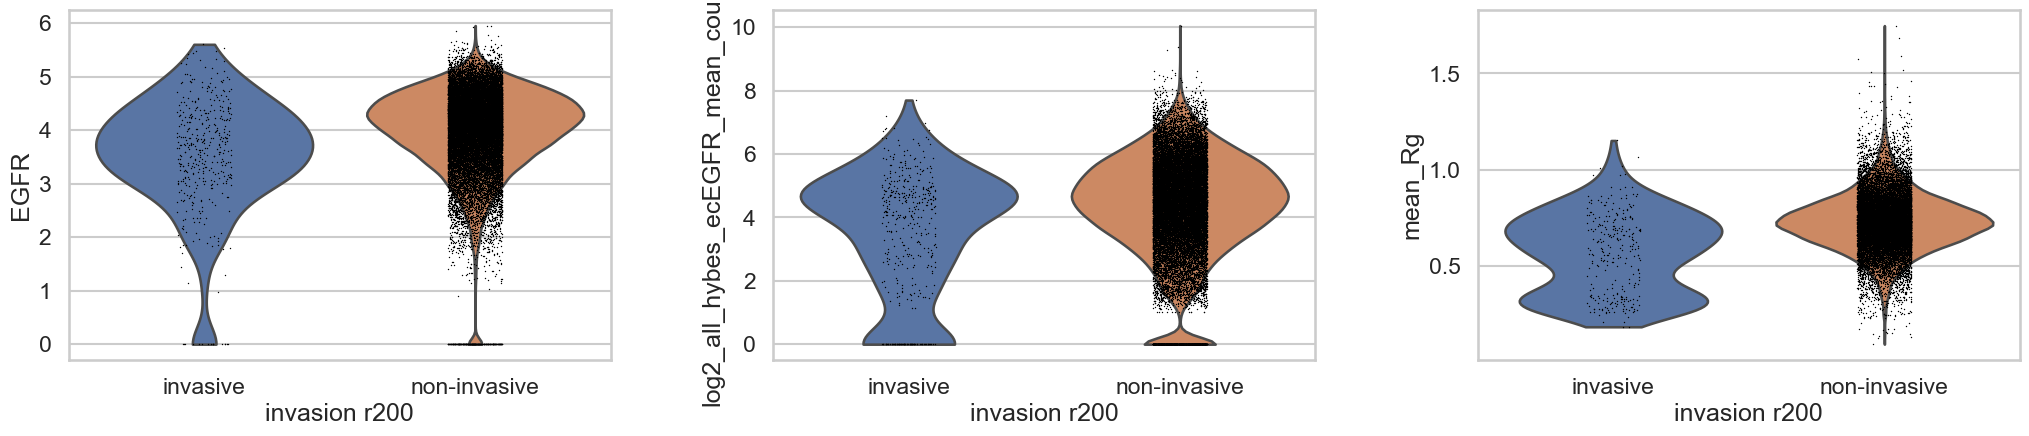

In [17]:
sc.pl.violin(adata, keys = ["EGFR", "log2_all_hybes_ecEGFR_mean_counts", "mean_Rg"], groupby = "invasion_r200")

In [18]:
# Can clean the above up aesthetically

In [19]:
import numpy as np, pandas as pd, seaborn as sns
import matplotlib as mpl, matplotlib.pyplot as plt
from scipy import sparse
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# ---- helper: pull a 1D series from obs/gene ----
def _series_from_key(adata, key, layer=None, use_raw=False):
    if key in adata.obs.columns:
        return pd.to_numeric(adata.obs[key], errors="coerce")
    if key in adata.var_names:
        if use_raw and (adata.raw is not None) and (key in adata.raw.var_names):
            Xg = adata.raw[:, key].X
        elif (layer is not None) and (layer in adata.layers):
            Xg = adata.layers[layer][:, adata.var_names.get_loc(key)]
        else:
            Xg = adata[:, key].X
        if sparse.issparse(Xg): Xg = Xg.toarray()
        return pd.Series(np.asarray(Xg).ravel(), index=adata.obs.index, name=key)
    raise KeyError(f"'{key}' not found as obs column or var gene.")

def seaborn_violin_with_box_stats_ttest(
    adata, keys, *,
    groupby="spatial_org_r100",
    order=("dispersed","clustered"),
    log1p_keys=None,
    palette=("tab:orange","tab:blue"),
    figsize_per_panel=(4.2, 4.2),
    title="",
    show_counts=True,
    layer=None, use_raw=False,
    save_svg=None, dpi=1200, rasterize_violins=False
):
    log1p_keys = set(log1p_keys or [])
    grp = adata.obs[groupby].astype("category")

    results = []
    dfs = []

    # prep per-key data + Welch t-test
    for k in keys:
        s = _series_from_key(adata, k, layer=layer, use_raw=use_raw)
        df = pd.DataFrame({groupby: grp, "value": s}).dropna()
        df = df[df[groupby].isin(order)].copy()
        if k in log1p_keys:
            df["value"] = np.log1p(df["value"])
        dfs.append((k, df))

        a = df.loc[df[groupby].eq(order[0]), "value"].to_numpy()
        b = df.loc[df[groupby].eq(order[1]), "value"].to_numpy()
        if a.size and b.size:
            tt = ttest_ind(a, b, equal_var=False, nan_policy="omit")
            # effect size (Cohen’s d; pooled SD with Welch’s suggestion)
            d = (np.nanmean(a) - np.nanmean(b)) / np.sqrt(0.5*(np.nanvar(a, ddof=1)+np.nanvar(b, ddof=1)))
            p = float(tt.pvalue)
            tstat = float(tt.statistic)
        else:
            tstat, p, d = np.nan, np.nan, np.nan

        results.append({"key": k, "t": tstat, "p": p, "cohens_d": d})

    # FDR across keys
    pvec = [1.0 if (not np.isfinite(r["p"])) else r["p"] for r in results]
    _, fdr, _, _ = multipletests(pvec, method="fdr_bh")
    for r, q in zip(results, fdr): r["fdr_bh"] = q
    stats_table = pd.DataFrame(results)

    # plotting
    n = len(keys)
    fig, axes = plt.subplots(1, n, figsize=(figsize_per_panel[0]*n, figsize_per_panel[1]), sharey=False)
    if n == 1:
        axes = [axes]

    for ax, (k, df), r in zip(axes, dfs, results):
        sns.violinplot(
            data=df, x=groupby, y="value",
            order=order, inner="box", cut=0, scale="width",
            linewidth=1, palette=palette, ax=ax
        )

        # ticks visible
        ax.tick_params(axis="x", which="both", bottom=True, top=False, length=4, width=0.8)
        ax.tick_params(axis="y", which="both", left=True,  right=False, length=4, width=0.8)

        # counts in x labels
        if show_counts:
            counts = df[groupby].value_counts().reindex(order).fillna(0).astype(int)
            ax.set_xticklabels([f"{lvl}\n(n={counts.loc[lvl]})" for lvl in order])

        ax.set_xlabel("")
        ax.set_title(k)
        if ax is not axes[0]:
            ax.set_ylabel("")

        # put stats above the panel
        ymin, ymax = np.nanmin(df["value"]), np.nanmax(df["value"])
        yr = ymax - ymin if np.isfinite(ymax - ymin) else 1.0
        ax.set_ylim(ymin - 0.05*yr, ymax + 0.18*yr)  # add headroom
        ax.grid(axis="y", color="0.9")

        txt = f"Welch t={r['t']:.2f}, p={r['p']:.2g}\nFDR={r['fdr_bh']:.2g}, d={r['cohens_d']:.2f}"
        ax.text(0.5, ymax + 0.12*yr, txt, ha="center", va="bottom", fontsize=11)

        # optionally rasterize the filled violins in the SVG
        if rasterize_violins:
            for coll in ax.collections:
                # matplotlib draws violins as PolyCollections
                try:
                    from matplotlib.collections import PolyCollection
                    if isinstance(coll, PolyCollection):
                        coll.set_rasterized(True)
                except Exception:
                    pass

    fig.suptitle(title, y=1.05)
    plt.tight_layout()

    if save_svg:
        mpl.rcParams["svg.fonttype"] = "none"  # keep text as text
        fig.savefig(save_svg, dpi=dpi, bbox_inches="tight")
        print("Saved →", save_svg)

    return stats_table


C:\Users\cfg001\AppData\Local\Temp\ipykernel_114628\365050061.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\cfg001\AppData\Local\Temp\ipykernel_114628\365050061.py:75: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\cfg001\AppData\Local\Temp\ipykernel_114628\365050061.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\cfg001\AppData\Local\Temp\ipykernel_114628\365050061.py:75: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\cfg

Saved → D:\BT\ecEGFR\manuscript\figures\figure_GBM39_mouse_3\neighbors\violin_invasion_ttest.svg


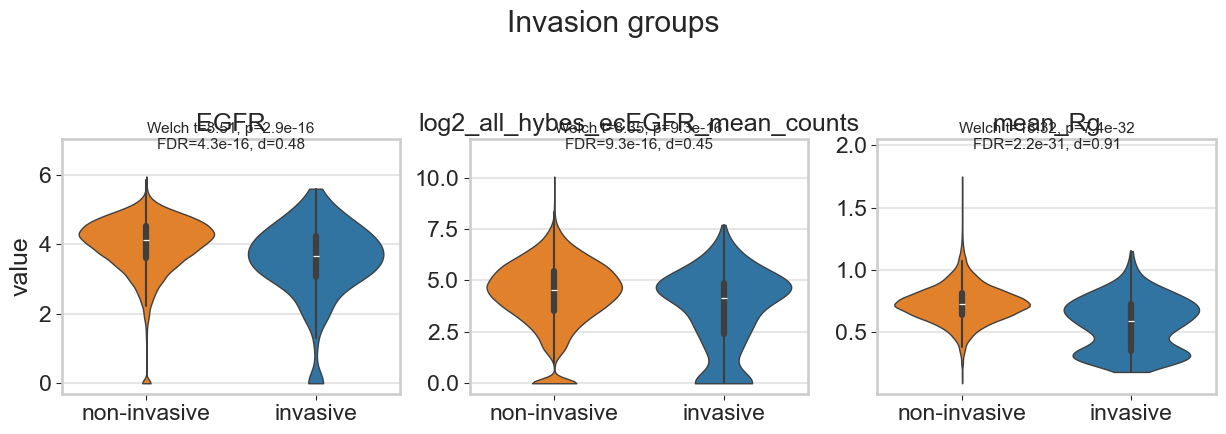

In [20]:
stats = seaborn_violin_with_box_stats_ttest(
    adata,
    keys=["EGFR", "log2_all_hybes_ecEGFR_mean_counts", "mean_Rg"],
    groupby="invasion_r200",
    order=("non-invasive","invasive"),
    title="Invasion groups",
    show_counts = False,
    save_svg=r"D:\BT\ecEGFR\manuscript\figures\figure_GBM39_mouse_3\neighbors\violin_invasion_ttest.svg",
    dpi=1200
)